In [2]:

import numpy as np
import matplotlib.pyplot as plt
from importlib import reload  
%matplotlib inline
import SatConAnalytic.skyBrightnessLib as SBlib
reload(SBlib)

darkSky_mag_arcsec2=22.0
moonSky_mag_arcsec2=18.0

Dark sky luminance: 1.74e-04 cd/m^2
Dark sky brightness: 5.47e-08 Lambert
Dark sky luminance: 1.74e-04 cd/m^2
Dark sky brightness: 5.47e-08 Lambert


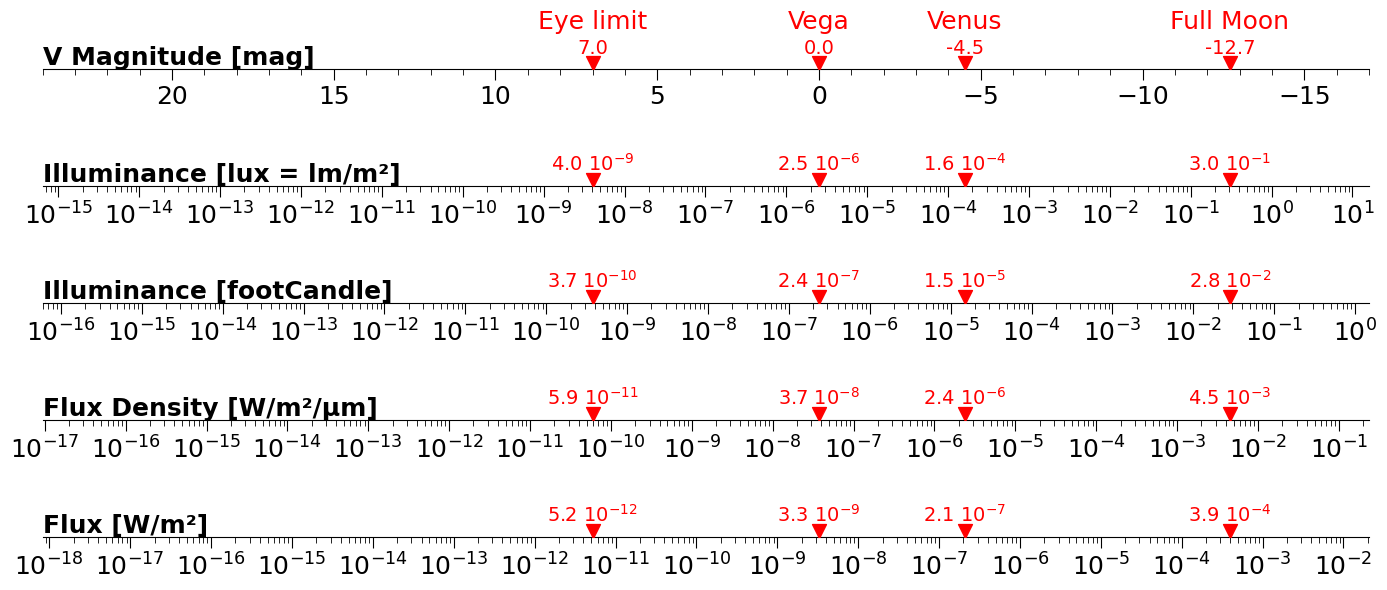

In [3]:
# magnitude to illuminance:


 # Create abacus with aligned scales
fig, axes = plt.subplots(5, 1, figsize=(14, 6))
textSize = 18

# Common x-axis: use magnitude as the reference (reversed: from 24 to 0)
x_min, x_max = 24, -17

#explMags = [0., -4.5, -12.7, -26.74]
#explLabels = ['Vega', 'Venus', 'Full Moon', 'Sun']
explMags = [7., 0., -4.5, -12.7]
explLabels = ['Eye limit','Vega', 'Venus', 'Full Moon']

# Configure each axis
for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='x', which='major', direction='out', length=8, labelsize=textSize)
    ax.tick_params(axis='x', which='minor', direction='out', length=4, labelsize=textSize)


    for mag in explMags:
        ax.scatter( mag, 0.1, color='r', marker='v', s=100, zorder=5)

for mag, label in zip(explMags, explLabels):
    axes[0].text( mag, 0.6, f"{label}", color='r', ha='center', va='bottom', size=textSize)




#==============================================================================
# Axis 1: Magnitude (linear) 
#==============================================================================
iax = axes[0]
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'V Magnitude [mag]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')
# Add minor ticks every 1 magnitude
from matplotlib.ticker import MultipleLocator
iax.xaxis.set_minor_locator(MultipleLocator(1))

for mag,lab in zip(explMags, explLabels):
    iax.text(mag, 0.2, f'{mag}', color='r', ha='center', va='bottom', 
             size=14)


#==============================================================================
# Axis 2: Illuminance (logarithmic scale) 
#==============================================================================
iax = axes[1]
# Map illuminance values to magnitude positions
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Illuminance [lux = lm/m²]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Create custom tick positions based on illuminance values - every decade
myTicks = 10.**np.arange(-18,2)
myTick_positions = []
myTick_labels = []

for illum in myTicks:
    # Find magnitude corresponding to this illuminance: illum 
    mag_pos = SBlib.illuminance_to_magnitude(illum)
    if x_max <= mag_pos <= x_min:  # Note: reversed comparison
        myTick_positions.append(mag_pos)
        #myTick_labels.append(f'{illum:.0e}')
        myTick_labels.append(f'$10^{{{np.log10(illum):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        illum_val = decade_start * i
        mag_pos = SBlib.illuminance_to_magnitude(illum_val)
        if x_max <= mag_pos <= x_min:  # Note: reversed comparison
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)

for mag,lab in zip(explMags, explLabels):
    iax.text(mag, 0.2, f'{SBlib.sci_to_label(SBlib.magnitude_to_illuminance(mag))}', color='r', ha='center', va='bottom', size=14)
    


#==============================================================================
# Axis 2b: Illuminance (logarithmic scale) - [footCandle]
#==============================================================================
iax = axes[2]
# Map illuminance values to magnitude positions
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Illuminance [footCandle]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Create custom tick positions based on illuminance values - every decade
# Extend the range to ensure ticks go all the way to mag=24
myTicks = 10.**np.arange(-18,2)
myTick_positions = []
myTick_labels = []

for f in myTicks:
    # Find magnitude corresponding to this illuminance: illum 
    mag_pos = SBlib.illuminance_to_magnitude(SBlib.illuminance_footcandle_to_lux(f))
    if x_max <= mag_pos <= x_min:  # Note: reversed comparison
        myTick_positions.append(mag_pos)
        myTick_labels.append(f'$10^{{{np.log10(f):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        f = decade_start * i
        mag_pos = SBlib.illuminance_to_magnitude(SBlib.illuminance_footcandle_to_lux(f))
        if x_max <= mag_pos <= x_min:  # Note: reversed comparison
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)

for mag,lab in zip(explMags, explLabels):
    iax.text(mag, 0.2, f'{SBlib.sci_to_label(SBlib.illuminance_lux_to_footcandle(SBlib.magnitude_to_illuminance(mag)))}', color='r', ha='center', va='bottom', size=14)



#==============================================================================
# Axis 3a: Flux Density (W/m²/μm) 
#==============================================================================
iax = axes[3]


# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Flux Density [W/m²/μm]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Create custom tick positions based on flux values - every decade
myTicks = 10.**(np.arange(-19, 1))  # in W/m2
myTick_positions = []
myTick_labels = []
for f in myTicks:
    mag_pos = SBlib.fluxDensity550nm_to_magnitude(f)  
    if x_max <= mag_pos <= x_min:  
        myTick_positions.append(mag_pos)
        myTick_labels.append(f'$10^{{{np.log10(f):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        flux_val = decade_start * i
        mag_pos = SBlib.fluxDensity550nm_to_magnitude(flux_val)
        if x_max <= mag_pos <= x_min:  
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)

for mag,lab in zip(explMags, explLabels):
    iax.text(mag, 0.2, f'{SBlib.sci_to_label(SBlib.magnitude_to_fluxDensity550nm(mag))}', color='r', ha='center', va='bottom', size=14)


#==============================================================================
# Axis 3b: Flux (W/m²) 
#==============================================================================
iax = axes[4]


# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Flux [W/m²]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Create custom tick positions based on flux values - every decade
myTicks = 10.**(np.arange(-19, 0))  # in W/m2
myTick_positions = []
myTick_labels = []
for f in myTicks:
    mag_pos = SBlib.flux_to_magnitude(f)  
    if x_max <= mag_pos <= x_min:  
        myTick_positions.append(mag_pos)
        myTick_labels.append(f'$10^{{{np.log10(f):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        flux_val = decade_start * i
        mag_pos = SBlib.flux_to_magnitude(flux_val)
        if x_max <= mag_pos <= x_min:  
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)

for mag,lab in zip(explMags, explLabels):
    iax.text(mag, 0.2, f'{SBlib.sci_to_label(SBlib.magnitude_to_flux(mag))}', color='r', ha='center', va='bottom', size=14)



# FINALIZE PLOT

plt.tight_layout()
#plt.subplots_adjust(hspace=0.4, right=0.88)  # Add right margin for labels
plt.savefig('abacus_magnitude.png', dpi=300)
plt.savefig('abacus_magnitude.pdf', dpi=300)




# Validation

https://stjarnhimlen.se/comp/radfaq.html#7:

- 1 mv=0 star outside Earth's atmosphere  = 2.54E-6 lux 
   --> Extinction ~0.1mag -> 2.27E-6 ; we get 2.1E-6 OK 
- Full Moon overhead:                      -12.5 mag = 0.267 lux --> we get -12.7mag = 0.26 OK
- A magnitude 6 star = 8.3 nanolux --> ~8.4 OK

Definition:
- 1 FtCandle = 10.764 lux: OK.

https://www.researchgate.net/post/Since_when_we_are_generating_power_from_lunar_light
- full moon, moonlight supplies only about 0.1–0.3 lux of illuminance:--> 0.26 OK.



Dark sky luminance: 1.74e-04 cd/m^2
Dark sky brightness: 5.47e-08 Lambert


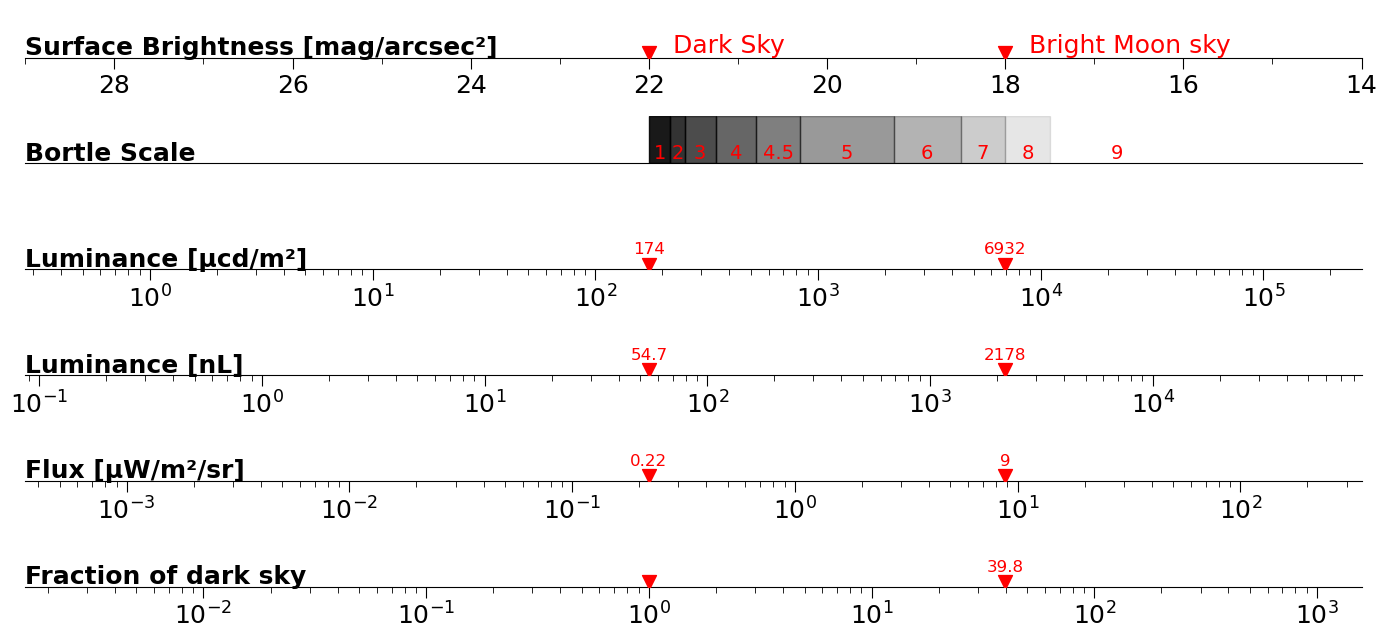

In [11]:
# surface brightness to Luminance

reload(SBlib)

# Create abacus with 6 aligned scales
fig, axes = plt.subplots(6, 1, figsize=(14, 6.5))

# Define magnitude range
# Common x-axis: use magnitude as the reference (reversed: from 24 to 0)
x_min, x_max = 29, 14

textSize = 18

# Configure each axis
for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params(axis='x', which='major', direction='out', length=8, labelsize=textSize)
    ax.tick_params(axis='x', which='minor', direction='out', length=4, labelsize=14)


def mark_references():
    # add marker for dark sky
    iax.scatter( darkSky_mag_arcsec2, 0.1, color='r', marker='v', s=100, zorder=5)

    iax.scatter( moonSky_mag_arcsec2, 0.1, color='r', marker='v', s=100, zorder=5)


iiax = 0

#==============================================================================
# Axis 1: Surface Brightness (magnitude per square arcsec) 
#==============================================================================
iax = axes[iiax]
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Surface Brightness [mag/arcsec²]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Add minor ticks every 1 magnitude
from matplotlib.ticker import MultipleLocator
iax.xaxis.set_minor_locator(MultipleLocator(1))

iax.text( darkSky_mag_arcsec2, 0.1, "   Dark Sky", color='r', ha='left', size=textSize)
iax.text( moonSky_mag_arcsec2, 0.1, "   Bright Moon sky", color='r', ha='left', size=textSize)

mark_references()
iiax += 1



#==============================================================================
# Axis 1: Bortle scale (magnitude per square arcsec)
#==============================================================================
iax = axes[iiax]
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Bortle Scale', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')



# beginning of each bortle class in mag/arcsec²
bortle_mags =   [22.0, 21.76, 21.6, 21.25, 20.8, 20.3, 19.25, 18.5, 18., 17.5, 16]
bortle_labels = ['1',  '2',   '3',  '4',  '4.5', '5',  '6',   '7', '8', '9']

#iax.set_xticks(bortle_mags)
iax.set_xticks([])
iax.set_xticklabels([])

for i in range(len(bortle_mags)-1):
    iax.axvspan(bortle_mags[i], bortle_mags[i+1], color='k', alpha=1-0.1*(i+1), zorder=0)
    iax.text((bortle_mags[i]+bortle_mags[i+1])/2, 0.1, bortle_labels[i], color='r', ha='center', size=14)

iiax += 1








#==============================================================================
# Axis 2: Luminance microcd/m² (logarithmic scale)
#==============================================================================
iax = axes[iiax]
# Map luminance values to magnitude positions
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Luminance [μcd/m²]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Create custom tick positions based on luminance values - every decade
myTicks = 10.**(np.arange(-7, 12) +6)  # in microcd/m²
myTick_positions = []
myTick_labels = []

for lum in myTicks:
    # Find magnitude corresponding to this luminance: lum = 10.8864E4 * 10**(-0.4*mag)
    mag_pos = SBlib.luminance_to_magarc2(lum * 1e-6)  # convert microcd/m² to cd/m²
    if x_max <= mag_pos <= x_min:  
        myTick_positions.append(mag_pos)
        myTick_labels.append(f'$10^{{{np.log10(lum):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        lum_val = decade_start * i
        mag_pos = SBlib.luminance_to_magarc2(lum_val * 1e-6)  # convert microcd/m² to cd/m²
        if x_max <= mag_pos <= x_min:  
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)
mark_references()
ytext = 0.25
iax.text(darkSky_mag_arcsec2, ytext, f'{SBlib.magarc2_to_luminance(darkSky_mag_arcsec2)*1e6:.0f}', color='r', ha='center', va='bottom', size=12)
iax.text(moonSky_mag_arcsec2, ytext, f'{SBlib.magarc2_to_luminance(moonSky_mag_arcsec2)*1e6:.0f}', color='r', ha='center', va='bottom', size=12)

iiax += 1

#==============================================================================
# Axis 3: nLambert (logarithmic scale) 
#==============================================================================
iax = axes[iiax]
# Map Lambert values to magnitude positions
iax.set_xlim(x_min, x_max)

# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Luminance [nL]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')

# Create custom tick positions based on nLambert values - every decade
myTicks = 10.**(np.arange(-3, 12) )  # in nLambert
myTick_positions = []
myTick_labels = []
for nlamb in myTicks:
    mag_pos = SBlib.lambert_to_magarc2(nlamb * 1e-9)
    if x_max <= mag_pos <= x_min:  
        myTick_positions.append(mag_pos)
        myTick_labels.append(f'$10^{{{np.log10(nlamb):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
lambert_minor_ticks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        lamb_val = decade_start * i  # in nLambert
        mag_pos = SBlib.lambert_to_magarc2(lamb_val * 1e-9)
        if x_max <= mag_pos <= x_min: 
            lambert_minor_ticks.append(mag_pos)


iax.set_xticks(lambert_minor_ticks, minor=True)
mark_references()
iax.text(darkSky_mag_arcsec2, ytext, 
         f'{SBlib.magarc2_to_lambert(darkSky_mag_arcsec2)*1e9:.1f}', 
         color='r', ha='center', va='bottom', size=12)
iax.text(moonSky_mag_arcsec2, ytext, 
         f'{SBlib.magarc2_to_lambert(moonSky_mag_arcsec2)*1e9:.0f}', 
         color='r', ha='center', va='bottom', size=12)

iiax += 1
#==============================================================================
# Axis 4: Flux (logarithmic scale)  'Flux [μW/m²/sr]'
#==============================================================================
iax = axes[iiax]
# Map flux values to magnitude positions
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Flux [μW/m²/sr]', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')
# Create custom tick positions based on flux values - every decade
myTicks = 10.**(np.arange(-10, 7)+6)  # in microW/m2/sr
myTick_positions = []
myTick_labels = []
for f in myTicks:
    mag_pos = SBlib.flux_to_magarc2(f * 1e-6)   # in W/m2/sr
    if x_max <= mag_pos <= x_min:  # Note: reversed comparison
        myTick_positions.append(mag_pos)
        myTick_labels.append(f'$10^{{{np.log10(f):.0f}}}$')
    
iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        flux_val = decade_start * i  * 1e-6 # in W/m2/sr
        mag_pos = SBlib.flux_to_magarc2(flux_val) 
        if x_max <= mag_pos <= x_min:  # Note: reversed comparison
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)

mark_references()
iax.text(darkSky_mag_arcsec2, ytext, f'{SBlib.magarc2_to_flux(darkSky_mag_arcsec2)*1e6:.2f}', color='r', ha='center', va='bottom', size=12)
iax.text(moonSky_mag_arcsec2, ytext, f'{SBlib.magarc2_to_flux(moonSky_mag_arcsec2)*1e6:.0f}', color='r', ha='center', va='bottom', size=12)

iiax += 1
#==============================================================================
# Axis 5: Ratio of dark sky 
#==============================================================================
iax = axes[iiax]
# Map flux values to magnitude positions
iax.set_xlim(x_min, x_max)
# Add text label at the left side of the line
iax.text(x_min, 0.2, 'Fraction of dark sky', fontsize=textSize, fontweight='bold', 
             ha='left', va='center')
# Create custom tick positions based on flux values - every decade
myTicks = 10.**np.arange(-3, 9)
myTick_positions = []
myTick_labels = []
for f in myTicks:
    mag_pos = SBlib.skyFraction_to_magarc2(f)
    if x_max <= mag_pos <= x_min:  # Note: reversed comparison
        myTick_positions.append(mag_pos)
        #myTick_labels.append(f'$10^{{{np.log10(f):.0f}}}$')
        #myTick_labels.append(f'{f:,.0f}')
        myTick_labels.append(f'$10^{{{np.log10(f):.0f}}}$')

iax.set_xticks(myTick_positions)
iax.set_xticklabels(myTick_labels)

# Add minor ticks: 9 per decade for log scale
myMinorTicks = []
for decade_start in myTicks:
    for i in range(2, 10):  # 2,3,4,5,6,7,8,9 gives 8 minor ticks per decade
        flux_val = decade_start * i
        mag_pos = SBlib.skyFraction_to_magarc2(flux_val)
        if x_max <= mag_pos <= x_min:  # Note: reversed comparison
            myMinorTicks.append(mag_pos)
iax.set_xticks(myMinorTicks, minor=True)
mark_references()

iax.text(moonSky_mag_arcsec2, ytext, f'{SBlib.magarc2_to_skyFraction(moonSky_mag_arcsec2):.1f}', color='r', ha='center', va='bottom', size=12)

iiax += 1

#plt.suptitle('Surface Brightness Abacus', fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
#plt.subplots_adjust(hspace=0.4, right=0.88)  # Add right margin for labels

plt.savefig('abacus_surfBrght.png', dpi=300)
plt.savefig('abacus_surfBrght.pdf', dpi=300)
plt.show()


# Validation

https://stjarnhimlen.se/comp/radfaq.html#7:

Clear sky 30 min after sunset (horiz)     0.1 cd/m2 =     +15 mag/a2  --> we get +15 == 0.1 OK



# Solar flux in V

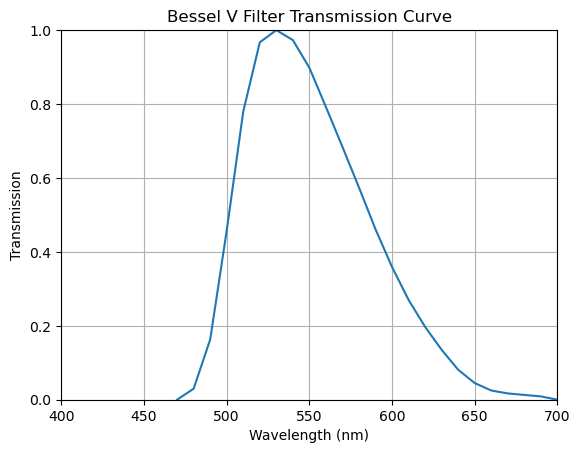

In [3]:
# read Bessel V and convert
file = 'Bessel_V.dat'
data = np.loadtxt(file)
Vwavelengths = data[:, 0]/10.  # in nm
Vtransmission = data[:, 1]
plt.plot(Vwavelengths, Vtransmission)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Bessel V Filter Transmission Curve')
plt.grid()
plt.xlim(400, 700)
plt.ylim(0, 1)
plt.show()

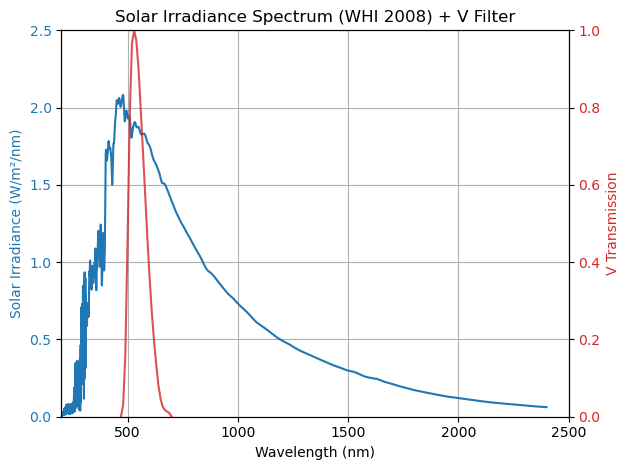

In [4]:
# read solar irradiance
from pathlib import Path

file = Path('ref_solar_irradiance_whi-2008_ver2.dat')

# Find first numeric data line (skip comments and header text)
data_start = None
with file.open('r') as f:
    for idx, line in enumerate(f):
        stripped = line.strip()
        if not stripped or stripped.startswith(';'):
            continue
        tokens = stripped.split()
        if len(tokens) < 2:
            continue
        try:
            float(tokens[0])
            float(tokens[1])
        except ValueError:
            continue
        data_start = idx
        break

if data_start is None:
    raise ValueError(f'No numeric data found in {file}')

data = np.loadtxt(file, comments=';', skiprows=data_start)
wavelengths = data[:, 0]  # in nm
irradiance = data[:, 1]   # in W/m²/nm

fig, ax1 = plt.subplots()
ax1.plot(wavelengths, irradiance, label="Sun", color="tab:blue")
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Solar Irradiance (W/m²/nm)', color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.grid()
ax1.set_xlim(200, 2500)
ax1.set_ylim(0, 2.5)

ax2 = ax1.twinx()
ax2.plot(Vwavelengths, Vtransmission, label="Bessel V", color="tab:red", alpha=0.8)
ax2.set_ylabel('V Transmission', color="tab:red")
ax2.set_ylim(0, 1)
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title('Solar Irradiance Spectrum (WHI 2008) + V Filter')
fig.tight_layout()
plt.show()

In [5]:
# integrate solar flux through V filter

# Interpolate V transmission to solar
Vtrans_interp = np.interp(wavelengths, Vwavelengths, Vtransmission, left=0, right=0)
# Multiply solar irradiance by V transmission
solar_V = irradiance * Vtrans_interp
# Integrate over wavelength using trapezoidal rule
solar_V_flux = np.trapz(solar_V, wavelengths)  # in W/m²
print(f'Solar flux through V filter: {solar_V_flux:.3f} W/m²')

Solar flux through V filter: 164.346 W/m²


In [70]:
reload(SBlib)


# irradiance at 550nm
irradiance_550nm = np.interp(550, wavelengths, irradiance)
print(f'Solar irradiance at 550 nm: {irradiance_550nm:.3f} W/m²/nm')
# conversion to W/m2/um
irradiance_550nm_um = irradiance_550nm * 1000.
print(f'Solar irradiance at 550 nm: {irradiance_550nm_um:.3f} W/m²/μm')

Solar irradiance at 550 nm: 1.873 W/m²/nm
Solar irradiance at 550 nm: 1873.300 W/m²/μm


In [8]:
reload(SBlib)
print(f'Dark sky surface brightness: {SBlib.darkSky_MpSA} mag/arcsec²')
print(f'Luminance: {SBlib.magarc2_to_luminance(SBlib.darkSky_MpSA)} cd/m²')

Dark sky luminance: 1.74e-04 cd/m^2
Dark sky brightness: 5.47e-08 Lambert
Dark sky surface brightness: 22.0 mag/arcsec²
Luminance: 0.00017413221505570227 cd/m²
